In [87]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ewwshika/maindataset/delivery_data.csv
/kaggle/input/datasets/ewwshika/eta-graph/final_normalized_graph.csv.xlsx
/kaggle/input/datasets/ewwshika/hubssss/hubs.json


In [88]:
import networkx as nx
data = pd.read_excel('/kaggle/input/datasets/ewwshika/eta-graph/final_normalized_graph.csv.xlsx')
main = pd.read_csv('/kaggle/input/datasets/ewwshika/maindataset/delivery_data.csv')


In [89]:
data.head(5)

,source_number,destination_number,is_carting,is_ftl,day_of_week,start_hour,osrm_time,osrm_distance,actual_distance,actual_time,real_actual_time_factor,data
0,0,1,1,0,2,2,-0.2881,-0.2773,-0.2805,-0.3603,1.6932,training
1,0,1,1,0,3,2,-0.2721,-0.2570,-0.2713,-0.3732,1.4773,training
2,0,1,1,0,3,3,-0.2721,-0.2576,-0.2712,-0.3655,1.5455,training
3,0,1,1,0,5,2,-0.2748,-0.2603,-0.2717,-0.3591,1.6200,training
4,1,504,1,0,1,4,-0.2614,-0.2571,-0.2463,-0.3346,1.7391,training


# Creating a graph of all the hubs as nodes

In [90]:
G = nx.from_pandas_edgelist(
    data,
    source='source_number',
    target='destination_number', create_using = nx.DiGraph)

# Calculating Betweenness Centrality 

In [91]:
bwfactor = nx.betweenness_centrality(G)
bwdata = pd.DataFrame(bwfactor.items(), columns=['node', 'bwcentrality'])
bwdata = bwdata.sort_values('bwcentrality', ascending=False)

bwdata.head(10)

,node,bwcentrality
7,30,0.216222
4,4,0.122431
17,109,0.090048
14,92,0.086506
3,2,0.056365
78,176,0.051163
5,14,0.044783
304,87,0.044059
10,57,0.042205
34,17,0.040173


# Calculating Closeness Centrality 

In [92]:
closenessfactor = nx.closeness_centrality(G)
closenessdata = pd.DataFrame(closenessfactor.items(), columns=['node', 'closeness'])
closenessdata = closenessdata.sort_values('closeness', ascending=False)
closenessdata.head(10)

,node,closeness
7,30,0.177128
4,4,0.165077
14,92,0.161799
17,109,0.160931
3,2,0.157513
10,57,0.156171
40,93,0.156023
6,26,0.154236
5,14,0.149859
35,21,0.149316


# Calculating Degree Centrality 

In [93]:
degreefactor = nx.degree_centrality(G)
degreedata = pd.DataFrame(degreefactor.items(), columns=['node', 'degree'])
degreedata = degreedata.sort_values('degree', ascending=False)
degreedata.head()

,node,degree
7,30,0.055734
4,4,0.045484
78,176,0.037156
17,109,0.035874
3,2,0.034593


In [94]:
top_in = sorted(G.in_degree(), key=lambda x: x[1], reverse=True)[:10]
print(top_in)
top_out = sorted(G.out_degree(), key=lambda x: x[1], reverse=True)[:10]
print(top_out)
top_overall = sorted(G.degree(), key=lambda x: x[1], reverse=True) [:10]
print(top_overall)

[(30, 41), (4, 36), (109, 30), (176, 30), (2, 27), (57, 22), (92, 21), (14, 19), (102, 18), (17, 18)]
[(30, 46), (4, 35), (176, 28), (2, 27), (109, 26), (102, 21), (92, 20), (57, 19), (14, 18), (17, 18)]
[(30, 87), (4, 71), (176, 58), (109, 56), (2, 54), (57, 41), (92, 41), (102, 39), (14, 37), (17, 36)]


In [95]:
data1 = pd.DataFrame()
data1['hub'] = list(G.nodes())

# Chronically delayed corridors
(actual transit time exceeds OSRM by more than 20%)

In [96]:
corridors = data.loc[:, ['actual_time', 'osrm_time','source_number', 'destination_number', 'osrm_time', 'actual_time']]
corridors['delay_ratio'] = (data['actual_time'] / data['osrm_time'])
data['delay_ratio'] = (data['actual_time'] / data['osrm_time'])
chronic_corridors = corridors[corridors['delay_ratio'] > 1.2].sort_values('delay_ratio', ascending=False)
chronic_corridors.loc[:, ['source_number', 'destination_number', 'delay_ratio']].sample(10)

,source_number,destination_number,delay_ratio
4216,87,102,1.219569
7746,283,284,1.209397
8491,348,817,1.236018
1239,5,241,1.288726
1028,5,4,1.593287
3403,57,2,25.666667
11018,610,611,9.284810
1754,18,19,1.403920
14264,1039,767,1.242122
14352,1057,1555,1.678251


In [97]:
#troublesome corridors
corridors['delay_ratio'].quantile(0.90)

np.float64(1.5907479263603335)

In [98]:
#severe corridors
corridors['delay_ratio'].quantile(0.95)

np.float64(2.2318173482723522)

In [99]:
# critical corridors
corridors['delay_ratio'].quantile(0.99)

np.float64(11.218578838808229)

#  Hubs with most SLA breaches


In [100]:
data['delay_hours'] = (data['actual_time'] - data['osrm_time']).clip(lower=0)

source_delay = (data.groupby('source_number')['delay_hours'].sum().reset_index().rename(columns={'source_number':'hub'}))

dest_delay = (data.groupby('destination_number')['delay_hours'].sum().reset_index().rename(columns={'destination_number':'hub'}))

hub_delay = pd.concat([source_delay, dest_delay])

hub_delay = (hub_delay.groupby('hub')['delay_hours'].sum().reset_index().sort_values('delay_hours', ascending=False))

In [101]:
hub_delay.head()

,hub,delay_hours
92,92,104.6005
30,30,98.6724
113,113,73.0322
2,2,60.3801
176,176,45.0346


In [102]:
data.head()

,source_number,destination_number,is_carting,is_ftl,day_of_week,start_hour,osrm_time,osrm_distance,actual_distance,actual_time,real_actual_time_factor,data,delay_ratio,delay_hours
0,0,1,1,0,2,2,-0.2881,-0.2773,-0.2805,-0.3603,1.6932,training,1.250607,0.0
1,0,1,1,0,3,2,-0.2721,-0.2570,-0.2713,-0.3732,1.4773,training,1.371555,0.0
2,0,1,1,0,3,3,-0.2721,-0.2576,-0.2712,-0.3655,1.5455,training,1.343256,0.0
3,0,1,1,0,5,2,-0.2748,-0.2603,-0.2717,-0.3591,1.6200,training,1.306769,0.0
4,1,504,1,0,1,4,-0.2614,-0.2571,-0.2463,-0.3346,1.7391,training,1.280031,0.0


In [103]:
delay_map = hub_delay.set_index('hub')['delay_hours']
data1['delay_hours'] = data1['hub'].map(delay_map)
data1.head()

,hub,delay_hours
0,0,0.0338
1,1,0.0000
2,504,0.2388
3,2,60.3801
4,4,26.8166


In [104]:
total_network_delay = hub_delay['delay_hours'].sum()
data1['sla_breach_contribution'] = (hub_delay['delay_hours']/ total_network_delay * 100)

# Developing a Framework to Find chokepoints 

In [105]:
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())
clustering = nx.clustering(G.to_undirected())
closeness_dict = dict(zip(closenessdata['node'], closenessdata['closeness']))
bw_dict = dict(zip(bwdata['node'],bwdata['bwcentrality']))
degree_dict = dict(zip(degreedata['node'], degreedata['degree']))

hub_metrics = pd.DataFrame({
    'hub': list(G.nodes()),
    'betweenness': [bw_dict[n] for n in G.nodes()],
    'degrees': [degree_dict[n] for n in G.nodes()],
    'clustering': [clustering[n] for n in G.nodes()],
    'closeness': [closeness_dict[n] for n in G.nodes()]
})

hub_ops = data1.groupby('hub').agg(
    total_delay_hrs    = ('delay_hours',         'sum'),
    sla_breach_contrib = ('sla_breach_contribution', 'mean'),
).reset_index()

hub_metrics = hub_metrics.merge(hub_ops, on='hub', how='left')
hub_metrics[['total_delay_hrs', 'sla_breach_contrib']] = \
    hub_metrics[['total_delay_hrs', 'sla_breach_contrib']].fillna(0)

In [106]:
from sklearn.preprocessing import MinMaxScaler

structural_cols  = ['betweenness', 'degrees', 'closeness', 'clustering']
operational_cols = ['total_delay_hrs', 'sla_breach_contrib']

hub_metrics[structural_cols]  = MinMaxScaler().fit_transform(hub_metrics[structural_cols])
hub_metrics[operational_cols] = MinMaxScaler().fit_transform(hub_metrics[operational_cols])

In [107]:
hub_metrics['structural_score'] = (
    0.50 * hub_metrics['betweenness']
  + 0.25 * hub_metrics['degrees']
  + 0.15 * hub_metrics['closeness']
  + 0.10 * (1 - hub_metrics['clustering'])
)

hub_metrics['performance_score'] = (
    0.40 * hub_metrics['total_delay_hrs']
  + 0.60 * hub_metrics['sla_breach_contrib']
)

hub_metrics['bottleneck_score'] = (
    0.50 * hub_metrics['structural_score']
  + 0.50 * hub_metrics['performance_score']
).round(6)

In [108]:
bottleneck_map = hub_metrics.set_index('hub')['bottleneck_score']
data1['bottleneck_score'] = data1['hub'].map(bottleneck_map)

In [109]:
data1.sort_values('bottleneck_score', ascending=False).head(5)

,hub,delay_hours,sla_breach_contribution,bottleneck_score
7,30,98.6724,0.001682,0.686816
14,92,104.6005,0.907108,0.530421
4,4,26.8166,1.249258,0.488876
92,566,6.5596,4.872842,0.407483
17,109,29.1936,0.656494,0.396384


In [110]:
data1.sort_values('sla_breach_contribution', ascending=False).head(5)

,hub,delay_hours,sla_breach_contribution,bottleneck_score
92,566,6.5596,4.872842,0.407483
30,1336,1.2223,4.596680,0.392604
113,1029,0.1761,3.402225,0.255862
2,504,0.2388,2.812823,0.276461
176,1094,2.1014,2.097949,0.254523


# csv output

In [111]:
import json

with open('/kaggle/input/datasets/ewwshika/hubssss/hubs.json') as f:
    hub_dict = json.load(f)

hub_compiled = pd.DataFrame(
    list(hub_dict.items()),
    columns=['hub_name', 'hub_number']
)

hub_compiled.head()

,hub_name,hub_number
0,Anand_VUNagar_DC (Gujarat),0
1,Khambhat_MotvdDPP_D (Gujarat),1
2,Bhiwandi_Mankoli_HB (Maharashtra),2
3,LowerParel_CP (Maharashtra),3
4,Bangalore_Nelmngla_H (Karnataka),4


In [112]:
data1.rename(columns={'hub': 'hub_number'}, inplace=True)
data1 = data1.sort_values('hub_number')
merge1 = pd.merge(data1, bwdata, left_on='hub_number', right_on='node', how='outer')
merge1.drop(columns={'node'}, inplace=True)
merge2 = pd.merge(merge1, closenessdata, left_on='hub_number', right_on='node', how='outer')
merge2.drop(columns={'node'}, inplace=True)
merge3 = pd.merge(merge2, degreedata, left_on='hub_number', right_on='node', how='outer')
merge3.drop(columns={'node'}, inplace=True)

hub_features = pd.merge(hub_compiled, merge3, on='hub_number', how='outer')


hub_features.rename(columns={
    'bwcentrality': 'betweenness_centrality',
    'closeness' : 'closeness_centrality', 
    'degree' : 'degree_centrality'
}, inplace=True)

hub_features.sample(10)

,hub_name,hub_number,delay_hours,sla_breach_contribution,bottleneck_score,betweenness_centrality,closeness_centrality,degree_centrality
384,Noida_Sec 02_DPC (Uttar Pradesh),384,2.1954,0.000000,0.122567,0.000841,0.144679,0.006406
1114,Hyderabad_Alwal_I (Telangana),1114,2.4370,0.102273,0.107167,0.002047,0.129179,0.003203
914,Chandauli_ShubsNGR_D (Uttar Pradesh),914,0.0913,0.000000,0.036919,0.000007,0.001171,0.001922
1380,Madnapalle_PngnrRd_D (Andhra Pradesh),1380,0.0000,0.000000,0.050000,0.000000,0.000000,0.000641
813,Sujangarh_LdnunDPP_D (Rajasthan),813,0.2559,0.011302,0.084064,0.004026,0.063222,0.001281
1026,Betamcherla_CmtNgRod_D (Andhra Pradesh),1026,0.0000,0.000000,0.087290,0.000416,0.083499,0.001281
119,Nandurbar_DhuleRd_D (Maharashtra),119,0.0000,0.063519,0.030595,0.000004,0.003052,0.004484
1402,Bareilly (Uttar Pradesh),1402,0.0884,0.000000,0.088089,0.000000,0.089556,0.000641
1104,Guwahati_UzanBazr_DC (Assam),1104,0.1129,0.066538,0.054312,0.000000,0.000000,0.000641
1526,Satana_ThrbadRD_D (Maharashtra),1526,0.0000,0.000121,0.051063,0.000000,0.002493,0.000641


In [113]:
hub_features.to_csv('hub-features.csv',index=False)

In [114]:
hub_features.sort_values('bottleneck_score', ascending=False).head(5)

,hub_name,hub_number,delay_hours,sla_breach_contribution,bottleneck_score,betweenness_centrality,closeness_centrality,degree_centrality
30,Gurgaon_Bilaspur_HB (Haryana),30,98.6724,0.001682,0.686816,0.216222,0.177128,0.055734
92,Kolkata_Dankuni_HB (West Bengal),92,104.6005,0.907108,0.530421,0.086506,0.161799,0.026265
4,Bangalore_Nelmngla_H (Karnataka),4,26.8166,1.249258,0.488876,0.122431,0.165077,0.045484
566,Rishikesh_DC (Uttarakhand),566,6.5596,4.872842,0.407483,0.000000,0.102704,0.001281
109,Hyderabad_Shamshbd_H (Telangana),109,29.1936,0.656494,0.396384,0.090048,0.160931,0.035874


# Top 10 Bottleneck Hubs

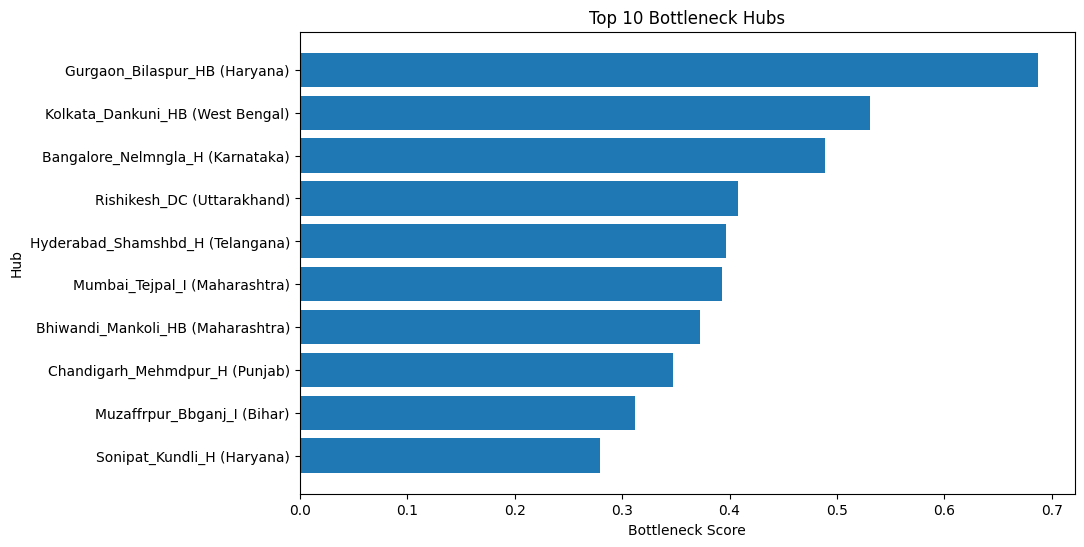

In [115]:
top10 = hub_features.sort_values('bottleneck_score', ascending=False).head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(
    top10['hub_name'],
    top10['bottleneck_score']
)

plt.xlabel('Bottleneck Score')
plt.ylabel('Hub')
plt.title('Top 10 Bottleneck Hubs')
plt.gca().invert_yaxis()

plt.show()

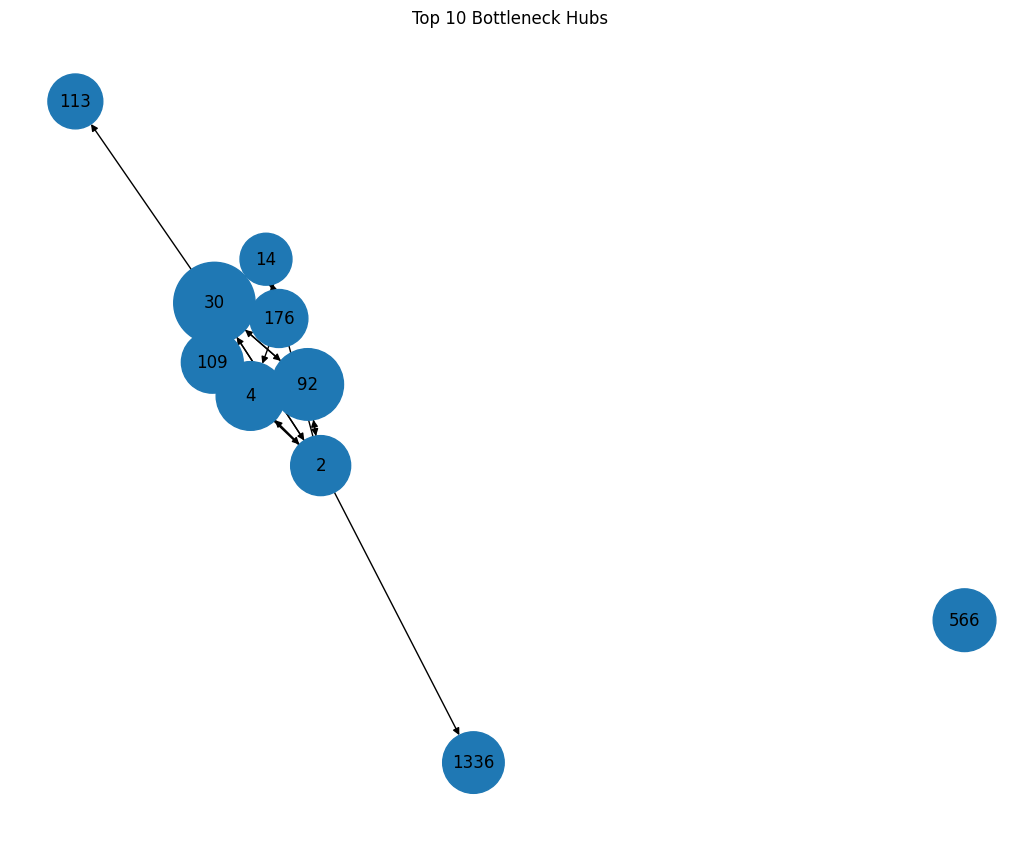

In [116]:
top_hubs = set(hub_features.nlargest(10, 'bottleneck_score')['hub_number'])

G_top = G.subgraph(top_hubs)

pos = nx.spring_layout(G_top, seed=42)

score_map = hub_features.set_index('hub_number')['bottleneck_score']

sizes = [
    score_map.loc[node] * 5000
    for node in G_top.nodes()
]

plt.figure(figsize=(10, 8))

nx.draw(
    G_top,
    pos,
    node_size=sizes,
    with_labels=True,
    arrows=True
)

plt.title("Top 10 Bottleneck Hubs")
plt.show()

# Hubs ranked by SLA Breaches

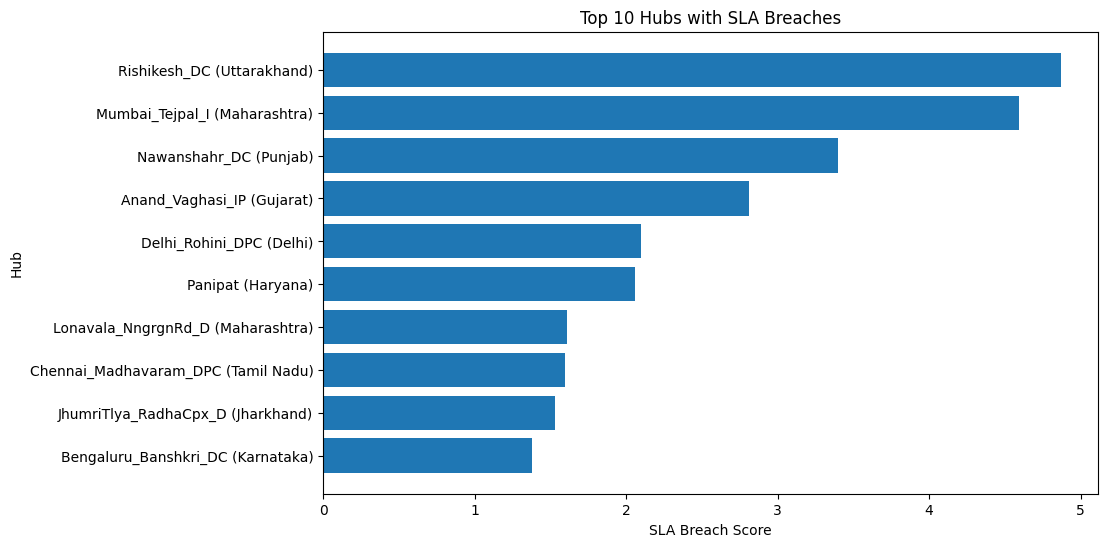

In [117]:
top10 = hub_features.sort_values('sla_breach_contribution', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(
    top10['hub_name'],
    top10['sla_breach_contribution']
)

plt.xlabel('SLA Breach Score')
plt.ylabel('Hub')
plt.title('Top 10 Hubs with SLA Breaches')
plt.gca().invert_yaxis()

plt.show()

# Graph of chronic corridors

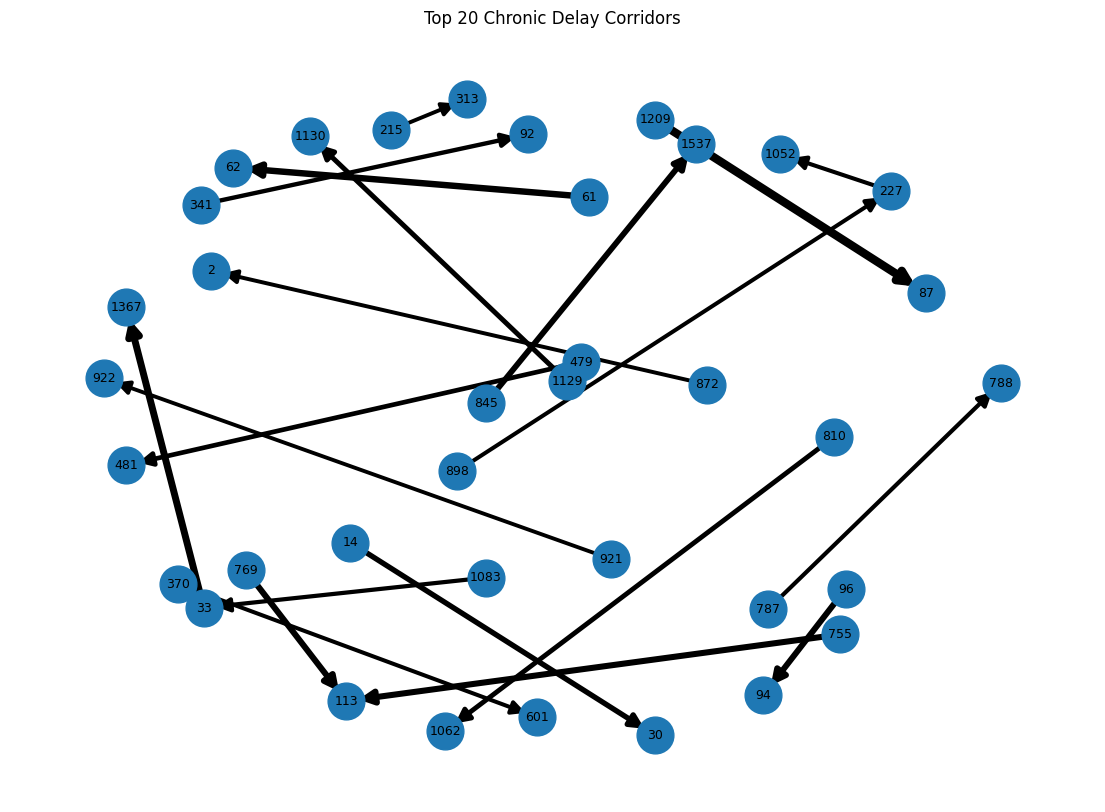

In [118]:
corridors = (
    data.groupby(['source_number', 'destination_number'])
    .agg(
        avg_delay_ratio=('delay_ratio', 'mean'),
        shipments=('delay_ratio', 'size')
    )
    .reset_index()
)

chronic_corridors = corridors.sort_values('avg_delay_ratio',ascending=False)
top_corridors = chronic_corridors.head(20)

G_delay = nx.from_pandas_edgelist(
    top_corridors,
    source='source_number',
    target='destination_number',
    edge_attr='avg_delay_ratio',
    create_using=nx.DiGraph()
)

pos = nx.spring_layout(G_delay,seed=42, k=1)

edge_widths = []

for _, _, d in G_delay.edges(data=True):
    width = np.log1p(d['avg_delay_ratio'])

    edge_widths.append(width)

max_width = max(edge_widths)
edge_widths = [1 + (w / max_width) * 5 for w in edge_widths]
plt.figure(figsize=(14,10))

nx.draw_networkx_nodes(
    G_delay,
    pos,
    node_size=700
)

nx.draw_networkx_labels(
    G_delay,
    pos,
    font_size=9
)

nx.draw_networkx_edges(
    G_delay,
    pos,
    width=edge_widths,
    arrows=True,
    arrowsize=20
)

plt.title("Top 20 Chronic Delay Corridors")
plt.axis('off')
plt.show()